In [97]:
import pandas as pd
df = pd.read_csv("MentalHealthSurvey.csv")

In [98]:
df.head()

,gender,age,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,average_sleep,study_satisfaction,...,academic_pressure,financial_concerns,social_relationships,depression,anxiety,Self-Efficacy,isolation,future_insecurity,stress_relief_activities,Mental-Health
0,Male,39,Undergraduate,Data Science,2nd year,3.0-3.5,Off-Campus,No,4-6 hrs,5,...,5,4,3,2,1,34.0,1,2,"Religious Activities, Social Connections, Onli...",28.0
1,Male,40,Postgraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,No,4-6 hrs,5,...,4,1,3,3,3,38.0,3,4,Online Entertainment,36.0
2,Male,39,Undergraduate,Computer Science,3rd year,2.5-3.0,Off-Campus,No,2-4 hrs,5,...,5,3,4,2,3,27.0,3,1,"Religious Activities, Sports and Fitness, Onli...",48.0
3,Male,28,Undergraduate,Computer Science,3rd year,2.5-3.0,On-Campus,No,4-6 hrs,3,...,4,4,1,5,5,24.0,5,3,Online Entertainment,44.0
4,Female,39,Undergraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,Yes,4-6 hrs,3,...,5,2,3,5,5,31.0,4,4,Online Entertainment,52.0


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   gender                    87 non-null     str    
 1   age                       87 non-null     int64  
 2   degree_level              87 non-null     str    
 3   degree_major              87 non-null     str    
 4   academic_year             87 non-null     str    
 5   cgpa                      87 non-null     str    
 6   residential_status        87 non-null     str    
 7   campus_discrimination     87 non-null     str    
 8   average_sleep             87 non-null     str    
 9   study_satisfaction        87 non-null     int64  
 10  academic_workload         87 non-null     int64  
 11  academic_pressure         87 non-null     int64  
 12  financial_concerns        87 non-null     int64  
 13  social_relationships      87 non-null     int64  
 14  depression             

In [100]:
df.describe

<bound method NDFrame.describe of     gender  age   degree_level            degree_major academic_year     cgpa  \
0     Male   39  Undergraduate            Data Science      2nd year  3.0-3.5   
1     Male   40   Postgraduate        Computer Science      3rd year  3.0-3.5   
2     Male   39  Undergraduate        Computer Science      3rd year  2.5-3.0   
3     Male   28  Undergraduate        Computer Science      3rd year  2.5-3.0   
4   Female   39  Undergraduate        Computer Science      3rd year  3.0-3.5   
..     ...  ...            ...                     ...           ...      ...   
82    Male   22  Undergraduate  Information Technology      4th year  3.0-3.5   
83  Female   22  Undergraduate    Software Engineering      4th year  3.5-4.0   
84    Male   21  Undergraduate            Data Science      2nd year  2.0-2.5   
85    Male   22  Undergraduate            Data Science      2nd year  2.5-3.0   
86  Female   19  Undergraduate            Data Science      2nd year  3.5-4

In [101]:
df.shape

(87, 21)

In [102]:
df.columns

Index(['gender', 'age', 'degree_level', 'degree_major', 'academic_year',
       'cgpa', 'residential_status', 'campus_discrimination', 'average_sleep',
       'study_satisfaction', 'academic_workload ', 'academic_pressure',
       'financial_concerns', 'social_relationships', 'depression', 'anxiety',
       'Self-Efficacy', 'isolation', 'future_insecurity',
       'stress_relief_activities', 'Mental-Health'],
      dtype='str')

In [103]:
df.isnull().sum()

gender                      0
age                         0
degree_level                0
degree_major                0
academic_year               0
cgpa                        0
residential_status          0
campus_discrimination       0
average_sleep               0
study_satisfaction          0
academic_workload           0
academic_pressure           0
financial_concerns          0
social_relationships        0
depression                  0
anxiety                     0
Self-Efficacy               9
isolation                   0
future_insecurity           0
stress_relief_activities    0
Mental-Health               9
dtype: int64

In [104]:
df['Self-Efficacy'] = df['Self-Efficacy'].fillna(df['Self-Efficacy'].mean())

In [105]:
df = df.dropna(subset=['Mental-Health'])

In [106]:
df.shape

(78, 21)

In [107]:
df.isnull().sum()

gender                      0
age                         0
degree_level                0
degree_major                0
academic_year               0
cgpa                        0
residential_status          0
campus_discrimination       0
average_sleep               0
study_satisfaction          0
academic_workload           0
academic_pressure           0
financial_concerns          0
social_relationships        0
depression                  0
anxiety                     0
Self-Efficacy               0
isolation                   0
future_insecurity           0
stress_relief_activities    0
Mental-Health               0
dtype: int64

In [110]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
73    False
74    False
75    False
76    False
77    False
Length: 78, dtype: bool

In [111]:
def categorize(score):
    if score <= 30:
        return "Low"
    elif score <= 50:
        return "Medium"
    else:
        return "High"

df['Risk_Level'] = df['Mental-Health'].apply(categorize)

In [112]:
df["Risk_Level"].unique()

<ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [113]:
from sklearn.preprocessing import LabelEncoder
import pickle

y = df["Risk_Level"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

pickle.dump(le, open("target_encoder.pkl", "wb"))

print(le.classes_)

['High' 'Low' 'Medium']


In [114]:
df.head()

,gender,age,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,average_sleep,study_satisfaction,...,financial_concerns,social_relationships,depression,anxiety,Self-Efficacy,isolation,future_insecurity,stress_relief_activities,Mental-Health,Risk_Level
0,Male,39,Undergraduate,Data Science,2nd year,3.0-3.5,Off-Campus,No,4-6 hrs,5,...,4,3,2,1,34.0,1,2,"Religious Activities, Social Connections, Onli...",28.0,Low
1,Male,40,Postgraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,No,4-6 hrs,5,...,1,3,3,3,38.0,3,4,Online Entertainment,36.0,Medium
2,Male,39,Undergraduate,Computer Science,3rd year,2.5-3.0,Off-Campus,No,2-4 hrs,5,...,3,4,2,3,27.0,3,1,"Religious Activities, Sports and Fitness, Onli...",48.0,Medium
3,Male,28,Undergraduate,Computer Science,3rd year,2.5-3.0,On-Campus,No,4-6 hrs,3,...,4,1,5,5,24.0,5,3,Online Entertainment,44.0,Medium
4,Female,39,Undergraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,Yes,4-6 hrs,3,...,2,3,5,5,31.0,4,4,Online Entertainment,52.0,High


In [115]:
df['cgpa'].unique()

<ArrowStringArray>
['3.0-3.5', '2.5-3.0', '3.5-4.0', '1.5-2.0', '2.0-2.5', '0.0-0.0']
Length: 6, dtype: str

In [116]:
def convert_range_to_float(x):
    if isinstance(x, str):  
        if '-' in x:
            low, high = x.split('-')
            return (float(low) + float(high)) / 2
        return float(x)  
    return x  
df['cgpa'] = df['cgpa'].apply(convert_range_to_float)

In [117]:
df['cgpa']

0     3.25
1     3.25
2     2.75
3     2.75
4     3.25
      ... 
73    3.25
74    3.75
75    3.75
76    2.75
77    3.25
Name: cgpa, Length: 78, dtype: float64

In [118]:
import numpy as np

def clean_sleep(x):
    try:
        x = str(x)
        if '-' in x:
            low, high = x.split('-')
            return (float(low) + float(high)) / 2
        else:
            import re
            match = re.search(r'\d+', x)
            return float(match.group()) if match else np.nan
    except:
        return np.nan

df['average_sleep'] = df['average_sleep'].apply(clean_sleep)

In [119]:
df['average_sleep']

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
      ..
73   NaN
74   NaN
75   NaN
76   NaN
77   NaN
Name: average_sleep, Length: 78, dtype: float64

In [120]:
categorical_cols = [
    'gender',
    'degree_level',
    'degree_major',
    'residential_status',
    'campus_discrimination'
]

In [121]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le   

In [122]:
df = df.drop('Mental-Health', axis=1)

In [123]:
df.head()

,gender,age,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,average_sleep,study_satisfaction,...,academic_pressure,financial_concerns,social_relationships,depression,anxiety,Self-Efficacy,isolation,future_insecurity,stress_relief_activities,Risk_Level
0,1,39,1,1,2nd year,3.25,0,0,NaN,5,...,5,4,3,2,1,34.0,1,2,"Religious Activities, Social Connections, Onli...",Low
1,1,40,0,0,3rd year,3.25,0,0,NaN,5,...,4,1,3,3,3,38.0,3,4,Online Entertainment,Medium
2,1,39,1,0,3rd year,2.75,0,0,NaN,5,...,5,3,4,2,3,27.0,3,1,"Religious Activities, Sports and Fitness, Onli...",Medium
3,1,28,1,0,3rd year,2.75,1,0,NaN,3,...,4,4,1,5,5,24.0,5,3,Online Entertainment,Medium
4,0,39,1,0,3rd year,3.25,0,1,NaN,3,...,5,2,3,5,5,31.0,4,4,Online Entertainment,High


In [124]:
df.info

<bound method DataFrame.info of     gender  age  degree_level  degree_major academic_year  cgpa  \
0        1   39             1             1      2nd year  3.25   
1        1   40             0             0      3rd year  3.25   
2        1   39             1             0      3rd year  2.75   
3        1   28             1             0      3rd year  2.75   
4        0   39             1             0      3rd year  3.25   
..     ...  ...           ...           ...           ...   ...   
73       0   19             1             0      3rd year  3.25   
74       1   21             1             1      1st year  3.75   
75       1   26             1             1      4th year  3.75   
76       0   19             1             0      3rd year  2.75   
77       1   22             1             2      4th year  3.25   

    residential_status  campus_discrimination  average_sleep  \
0                    0                      0            NaN   
1                    0             

In [125]:
df['cgpa'].unique()

array([3.25, 2.75, 3.75, 1.75, 2.25, 0.  ])

In [126]:
df['cgpa'].value_counts()

cgpa
3.25    24
3.75    24
2.75    20
0.00     5
2.25     3
1.75     2
Name: count, dtype: int64

In [127]:
df['cgpa'] = df['cgpa'].replace(0, None)
df['cgpa'] = df['cgpa'].fillna(df['cgpa'].mean())

In [128]:
df['cgpa'].describe()

count     78.00
unique     6.00
top        3.25
freq      24.00
Name: cgpa, dtype: float64

In [129]:
df['cgpa'] = pd.to_numeric(df['cgpa'], errors='coerce')

In [130]:
df['cgpa'] = df['cgpa'].fillna(df['cgpa'].mean())

In [131]:
df['cgpa'].describe()

count    78.000000
mean      3.195205
std       0.487251
min       1.750000
25%       2.750000
50%       3.250000
75%       3.750000
max       3.750000
Name: cgpa, dtype: float64

In [132]:
print(df.columns.tolist())

['gender', 'age', 'degree_level', 'degree_major', 'academic_year', 'cgpa', 'residential_status', 'campus_discrimination', 'average_sleep', 'study_satisfaction', 'academic_workload ', 'academic_pressure', 'financial_concerns', 'social_relationships', 'depression', 'anxiety', 'Self-Efficacy', 'isolation', 'future_insecurity', 'stress_relief_activities', 'Risk_Level']


In [133]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

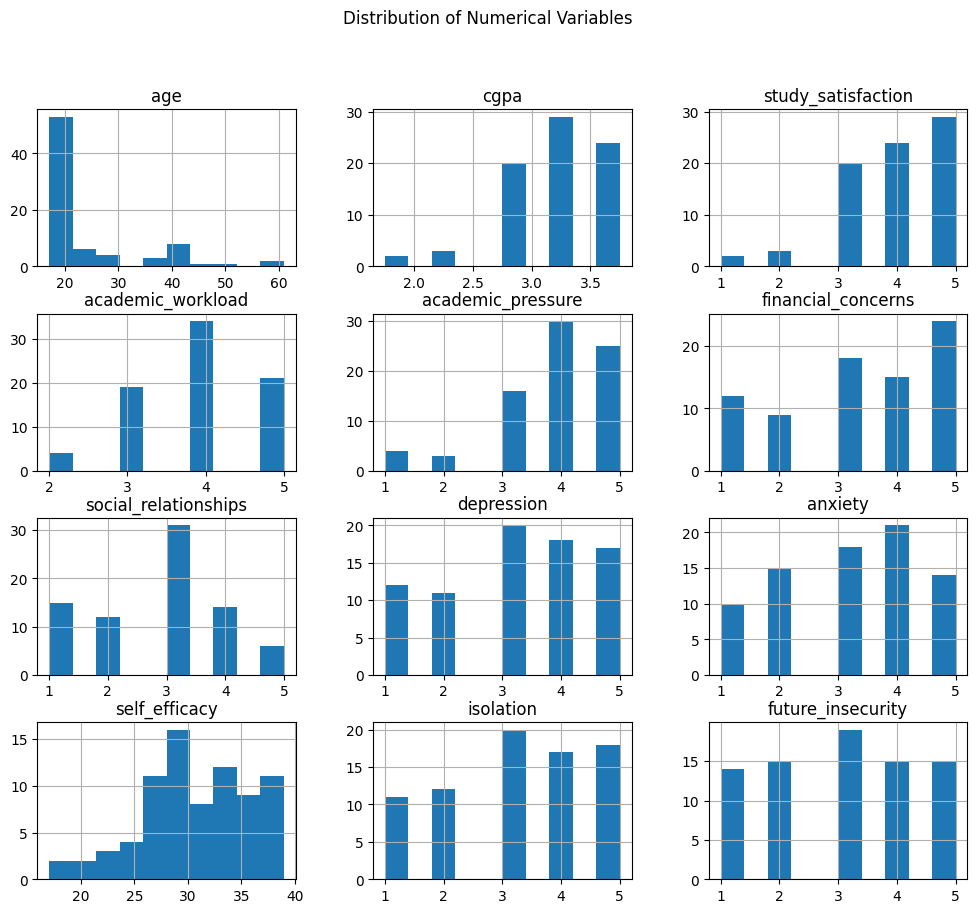

In [134]:
import matplotlib.pyplot as plt
num_cols = ['age','cgpa','study_satisfaction','academic_workload',
            'academic_pressure','financial_concerns','social_relationships',
            'depression','anxiety','self_efficacy','isolation','future_insecurity']

df[num_cols].hist(figsize=(12,10))
plt.suptitle('Distribution of Numerical Variables')
plt.show()

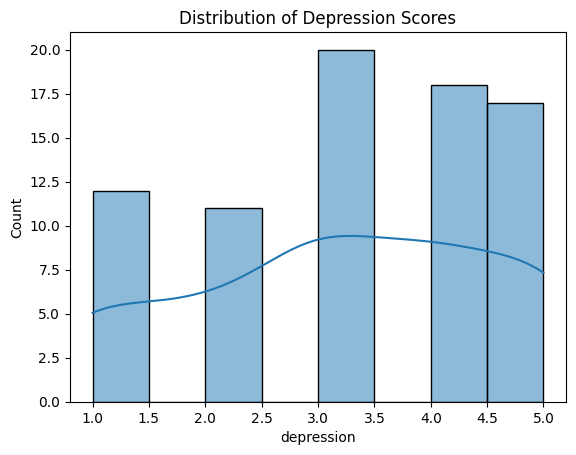

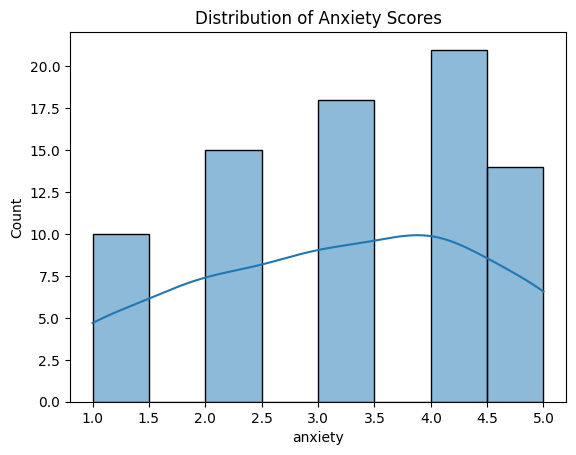

In [135]:
import seaborn as sns
sns.histplot(df['depression'], kde=True)
plt.title('Distribution of Depression Scores')
plt.show()

sns.histplot(df['anxiety'], kde=True)
plt.title('Distribution of Anxiety Scores')
plt.show()

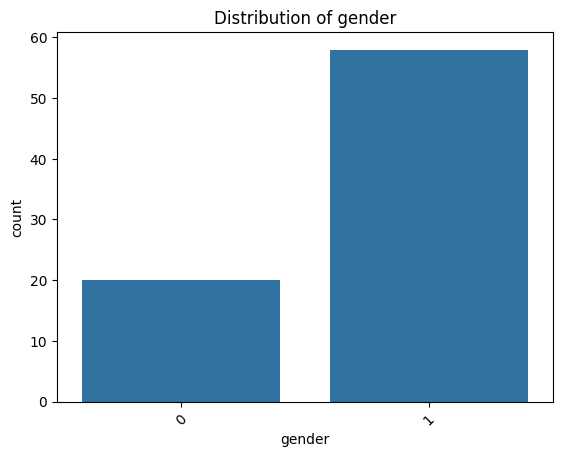

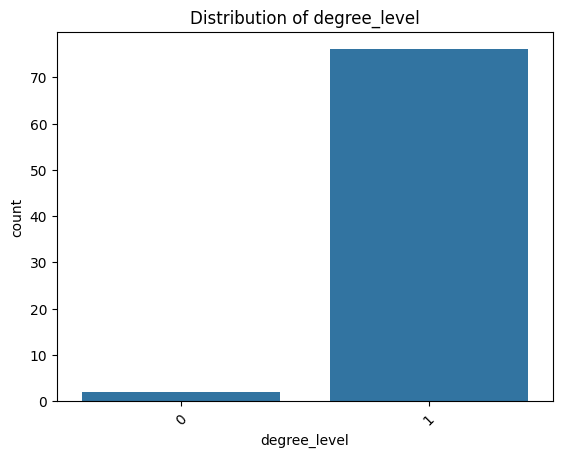

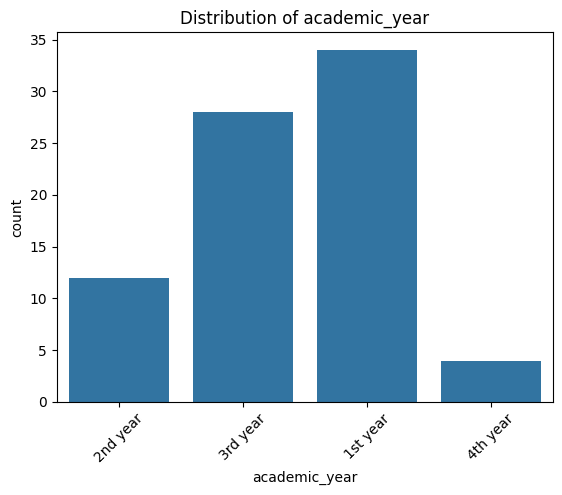

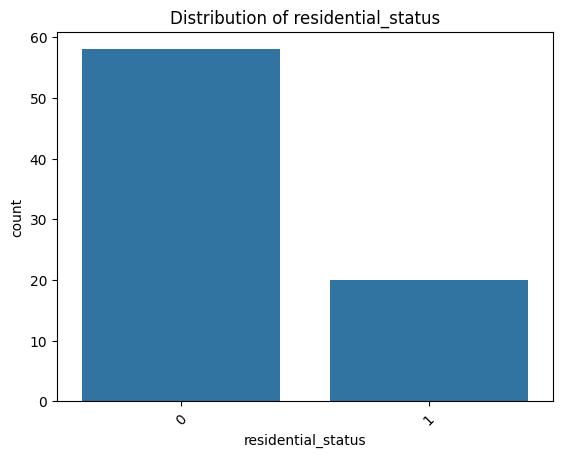

In [136]:
cat_cols = ['gender','degree_level','academic_year','residential_status']

for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

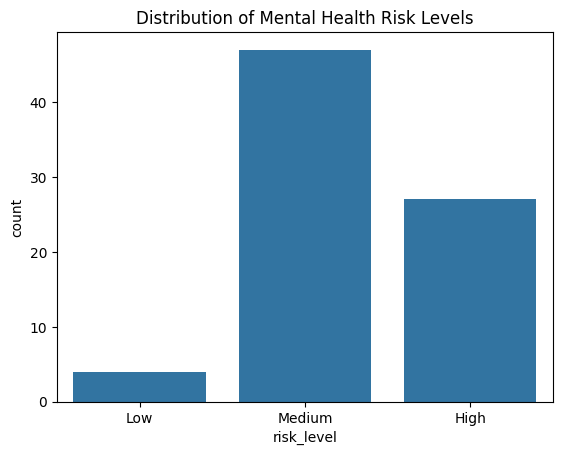

In [137]:
sns.countplot(x='risk_level', data=df)
plt.title('Distribution of Mental Health Risk Levels')
plt.show()

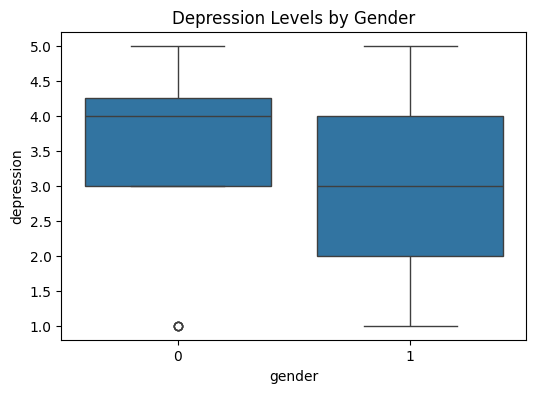

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='depression', data=df)
plt.title('Depression Levels by Gender')
plt.show()

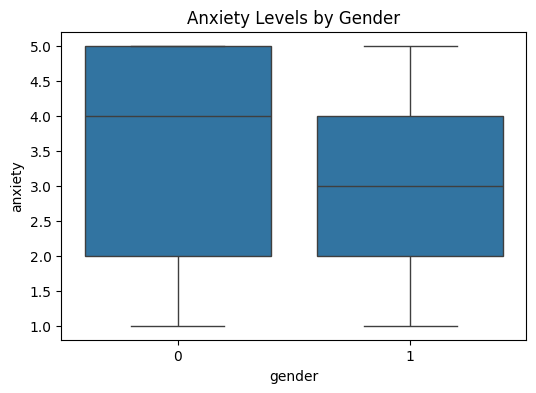

In [139]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='anxiety', data=df)
plt.title('Anxiety Levels by Gender')
plt.show()

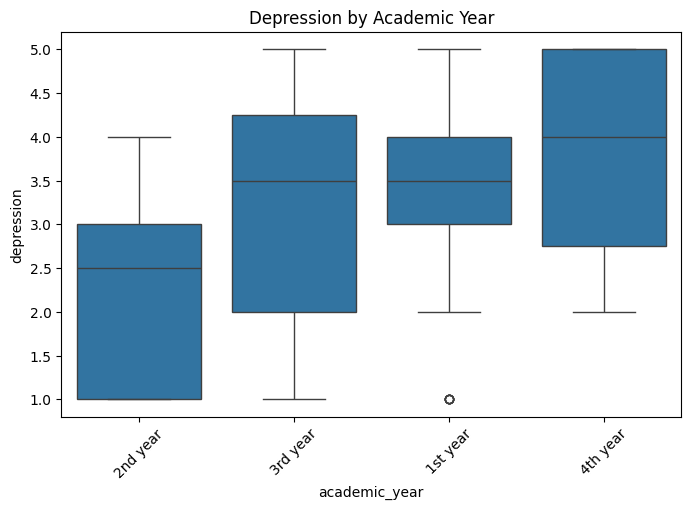

In [140]:
plt.figure(figsize=(8,5))
sns.boxplot(x='academic_year', y='depression', data=df)
plt.title('Depression by Academic Year')
plt.xticks(rotation=45)
plt.show()

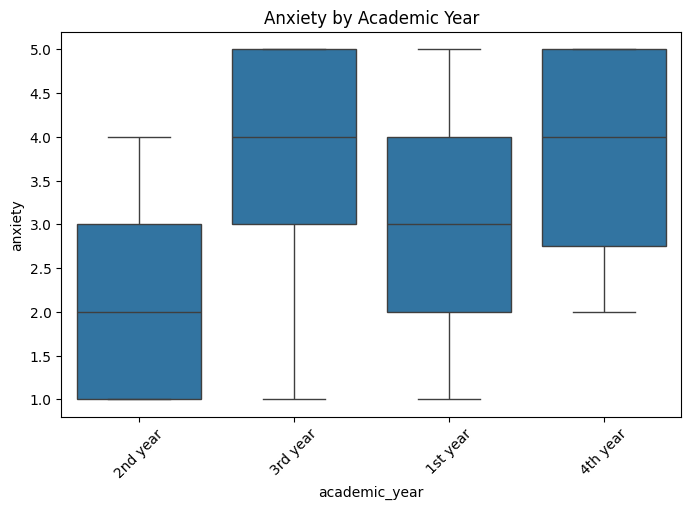

In [141]:
plt.figure(figsize=(8,5))
sns.boxplot(x='academic_year', y='anxiety', data=df)
plt.title('Anxiety by Academic Year')
plt.xticks(rotation=45)
plt.show()

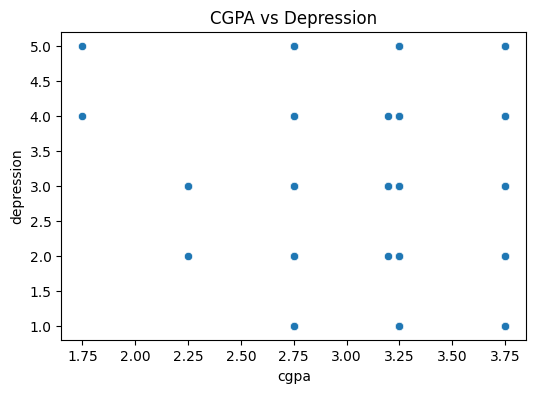

In [142]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='cgpa', y='depression', data=df)
plt.title('CGPA vs Depression')
plt.show()

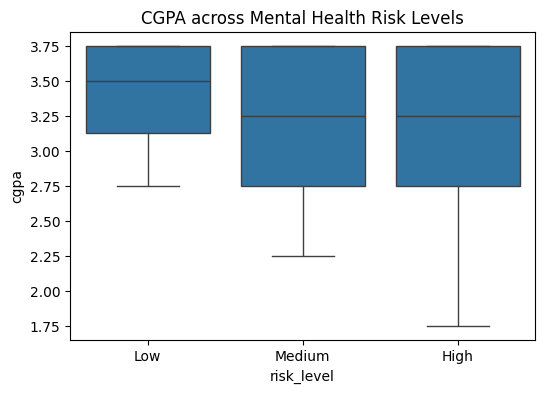

In [143]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_level', y='cgpa', data=df)
plt.title('CGPA across Mental Health Risk Levels')
plt.show()

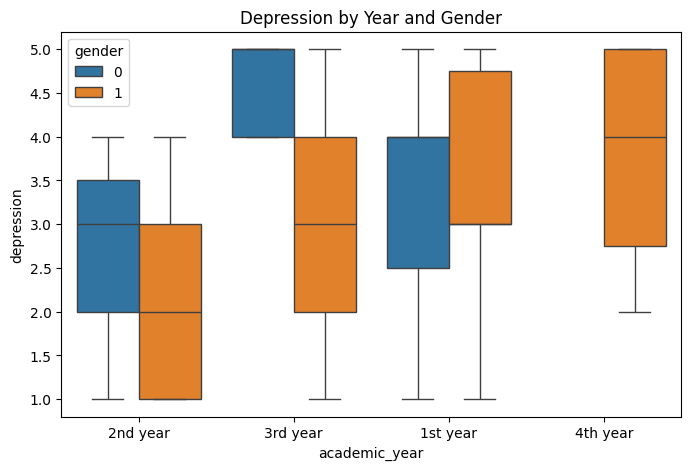

In [144]:
plt.figure(figsize=(8,5))
sns.boxplot(x='academic_year', y='depression', hue='gender', data=df)
plt.title('Depression by Year and Gender')
plt.show()

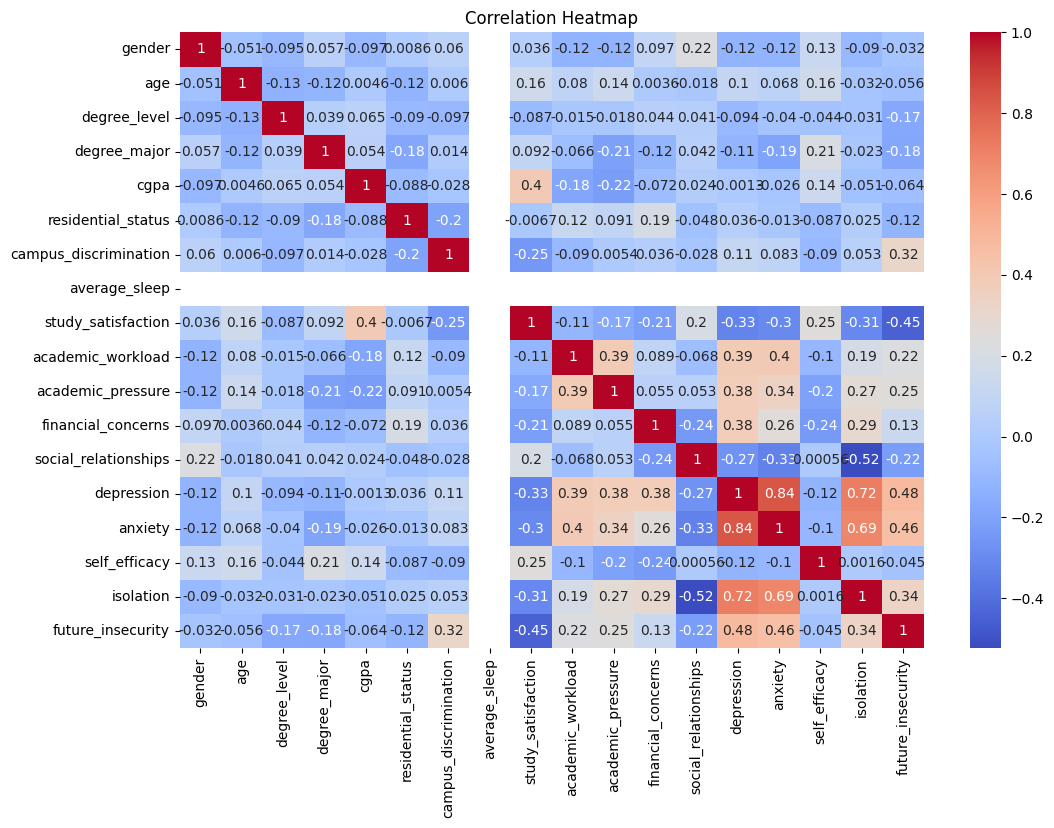

In [145]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

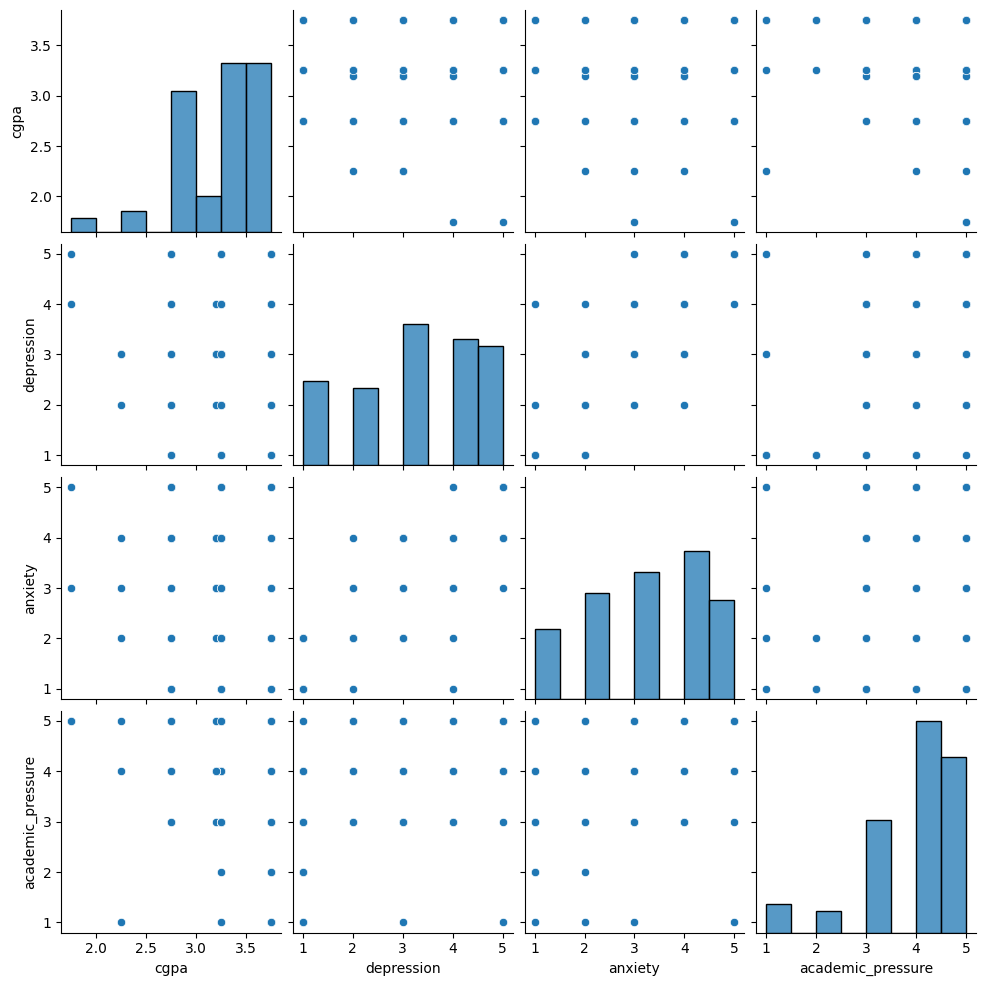

In [146]:
sns.pairplot(df[['cgpa','depression','anxiety','academic_pressure']])
plt.show()

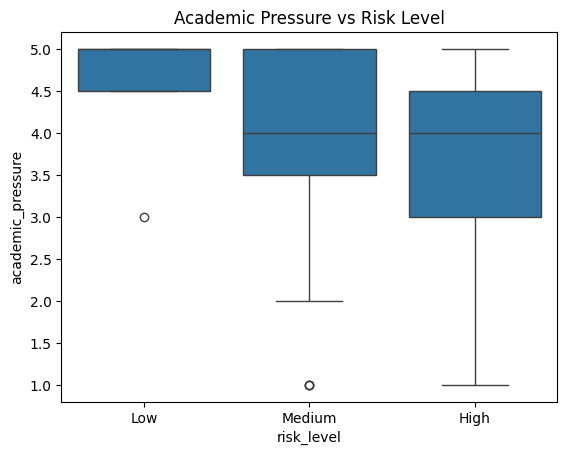

In [147]:
sns.boxplot(x='risk_level', y='academic_pressure', data=df)
plt.title('Academic Pressure vs Risk Level')
plt.show()

In [148]:
pd.crosstab(df['gender'], df['risk_level'])

risk_level,High,Low,Medium
gender,,,
0,11,0,9
1,16,4,38


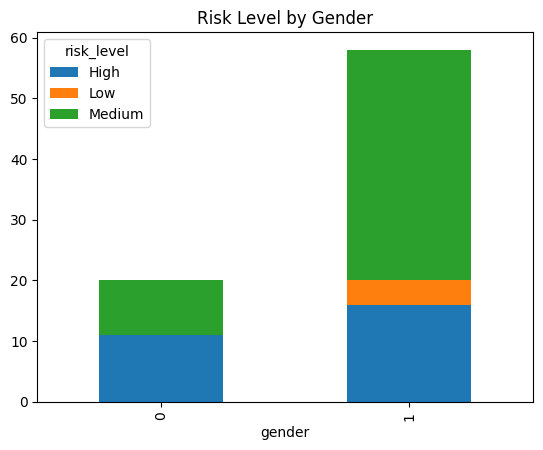

In [149]:
pd.crosstab(df['gender'], df['risk_level']).plot(kind='bar', stacked=True)
plt.title('Risk Level by Gender')
plt.show()

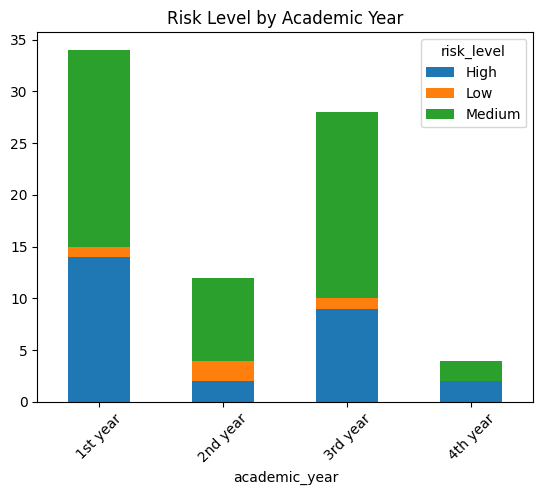

In [150]:
pd.crosstab(df['academic_year'], df['risk_level']).plot(kind='bar', stacked=True)
plt.title('Risk Level by Academic Year')
plt.xticks(rotation=45)
plt.show()

In [ ]:
y = df['risk_level']